In [8]:
from ase.units import Ry
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [9]:
def plot_convergence(title_pseudo: str, path_energy_data = './energy_data/energies.csv'):
    df = pd.read_csv(path_energy_data, names=['file', 'energy (Ry)'])
    
    # Extraindo ecutwfc e ecutrho do nome do arquivo
    df['wfc'] = df['file'].str.extract(r'wfc(\d+)').astype(int)
    df['rho'] = df['file'].str.extract(r'rho(\d+)').astype(int)

    # Energia por átomo
    df['E_atom (eV)'] = (df['energy (Ry)']* Ry ) / 4
    df['diff_minE_meV'] = (df['E_atom (eV)'] - df['E_atom (eV)'].min()) * 1_000
    
    print('Plotting data from df.')
    display(df)
    # Plot
    fig, ax = plt.subplots(figsize=(6,5))
    ax.set_title(title_pseudo)
    ax.set_xlabel('Energy Cut-Off (Ry)',labelpad=5)
    ax.set_ylabel('E/atom (eV)', labelpad=5)

    ax.scatter(df['wfc'], df['E_atom (eV)'], marker='x', color='r')
    ax.plot(df['wfc'], df['E_atom (eV)'], color='black')


    # TEXT 
    for i, txt in enumerate(df['diff_minE_meV']):
        if i == 0:
            ax.text(df['wfc'][i]+1, df['E_atom (eV)'][i]+0.05, s=r"$\Delta E$: "+f'{txt:.2f} meV', fontsize=8, ha='left', va='bottom', rotation=0)
        else:
            ax.text(df['wfc'][i]+1, df['E_atom (eV)'][i] +0.05, f'{txt:.2f} meV', fontsize=8, ha='left', va='bottom', rotation=45)
    # END TEXT
    ax.set_xticks(range(20,130,10))
    ax.set_xlim([15,140])
    plt.show()

Plotting data from df.


,file,energy (Ry),wfc,rho,E_atom (eV),diff_minE_meV
0,scf_wfc20_rho80.out,-825.279989,20,80,-2807.126545,260387.127076
1,scf_wfc30_rho120.out,-875.995188,30,120,-2979.630401,87883.270799
2,scf_wfc40_rho160.out,-894.928946,40,160,-3044.032125,23481.546955
3,scf_wfc50_rho200.out,-900.523311,50,200,-3063.060930,4452.742295
4,scf_wfc60_rho240.out,-901.678778,60,240,-3066.991162,522.509973
5,scf_wfc70_rho280.out,-901.822828,70,280,-3067.481138,32.534307
6,scf_wfc80_rho320.out,-901.832147,80,320,-3067.512835,0.837464
7,scf_wfc90_rho360.out,-901.832344,90,360,-3067.513507,0.165343
8,scf_wfc100_rho400.out,-901.832363,100,400,-3067.513569,0.103505
9,scf_wfc110_rho440.out,-901.832377,110,440,-3067.513619,0.052994


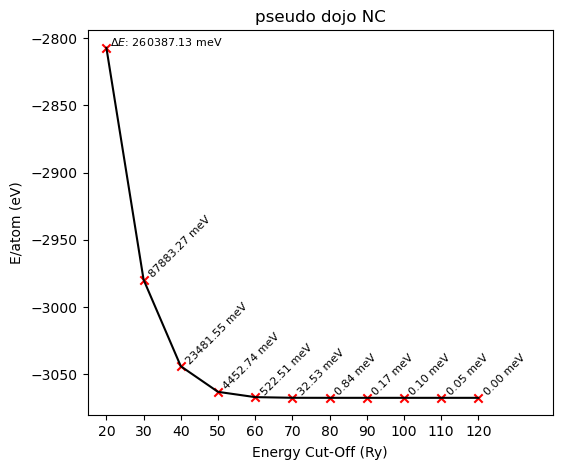

In [10]:
plot_convergence('pseudo dojo NC')